In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as  plt
import scipy.stats as stats
import warnings
pd.options.display.max_columns=None

In [2]:
df= pd.read_csv('/kaggle/input/llm-detect-ai-generated-text/test_essays.csv')
df.head()

,id,prompt_id,text
0,0000aaaa,2,Aaa bbb ccc.
1,1111bbbb,3,Bbb ccc ddd.
2,2222cccc,4,CCC ddd eee.


In [7]:
train = pd.read_csv('/kaggle/input/llm-detect-ai-generated-text/train_essays.csv')
train.head()

,id,prompt_id,text,generated
0,0059830c,0,Cars. Cars have been around since they became ...,0
1,005db917,0,Transportation is a large necessity in most co...,0
2,008f63e3,0,"""America's love affair with it's vehicles seem...",0
3,00940276,0,How often do you ride in a car? Do you drive a...,0
4,00c39458,0,Cars are a wonderful thing. They are perhaps o...,0


In [8]:
train1 = pd.read_csv('/kaggle/input/llm-detect-ai-generated-text/train_prompts.csv')
train1.head()

,prompt_id,prompt_name,instructions,source_text
0,0,Car-free cities,Write an explanatory essay to inform fellow ci...,"# In German Suburb, Life Goes On Without Cars ..."
1,1,Does the electoral college work?,Write a letter to your state senator in which ...,# What Is the Electoral College? by the Office...


In [10]:
test = pd.read_csv('/kaggle/input/llm-detect-ai-generated-text/test_essays.csv')
test.head()

,id,prompt_id,text
0,0000aaaa,2,Aaa bbb ccc.
1,1111bbbb,3,Bbb ccc ddd.
2,2222cccc,4,CCC ddd eee.


In [11]:
combined = pd.concat([df,test,train,train1])
combined.head()

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,prompt_id,text,generated,prompt_name,instructions,source_text
0,0000aaaa,2,Aaa bbb ccc.,NaN,NaN,NaN,NaN
1,1111bbbb,3,Bbb ccc ddd.,NaN,NaN,NaN,NaN
2,2222cccc,4,CCC ddd eee.,NaN,NaN,NaN,NaN
0,0000aaaa,2,Aaa bbb ccc.,NaN,NaN,NaN,NaN
1,1111bbbb,3,Bbb ccc ddd.,NaN,NaN,NaN,NaN


In [12]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1386 entries, 0 to 1
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            1384 non-null   object 
 1   prompt_id     1386 non-null   int64  
 2   text          1384 non-null   object 
 3   generated     1378 non-null   float64
 4   prompt_name   2 non-null      object 
 5   instructions  2 non-null      object 
 6   source_text   2 non-null      object 
dtypes: float64(1), int64(1), object(5)
memory usage: 86.6+ KB


In [13]:
combined.dtypes

id               object
prompt_id         int64
text             object
generated       float64
prompt_name      object
instructions     object
source_text      object
dtype: object

In [14]:
combined.columns

Index(['id', 'prompt_id', 'text', 'generated', 'prompt_name', 'instructions',
       'source_text'],
      dtype='object')

In [15]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
prompt_id,1386.0,0.497114,0.528255,0.0,0.0,0.0,1.0,4.0
generated,1378.0,0.002177,0.046625,0.0,0.0,0.0,0.0,1.0


In [16]:
combined.shape

(1386, 7)

In [17]:
combined.isnull().sum()/len(combined)*100

id               0.144300
prompt_id        0.000000
text             0.144300
generated        0.577201
prompt_name     99.855700
instructions    99.855700
source_text     99.855700
dtype: float64

<Axes: >

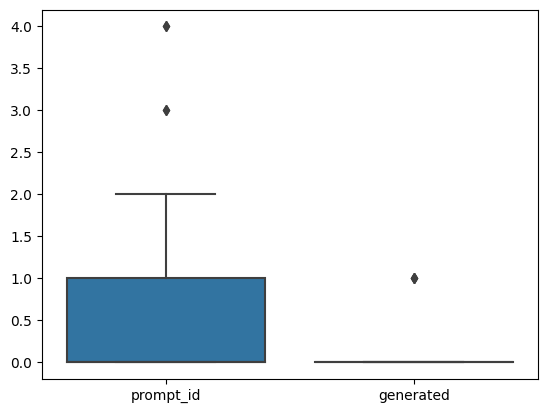

In [18]:
sns.boxplot(combined)

<Axes: >

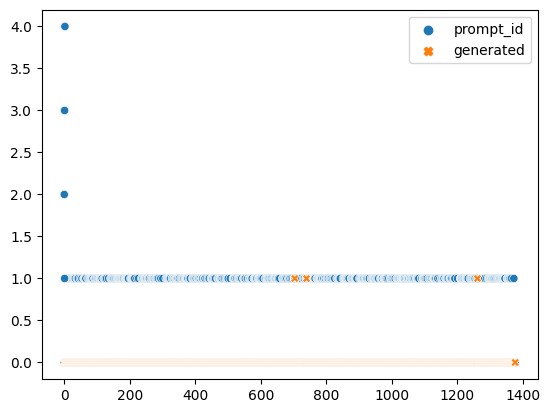

In [19]:
sns.scatterplot(combined)

<Axes: >

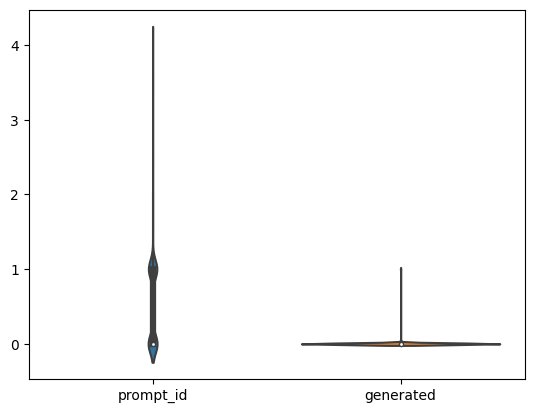

In [20]:
sns.violinplot(combined)

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: >

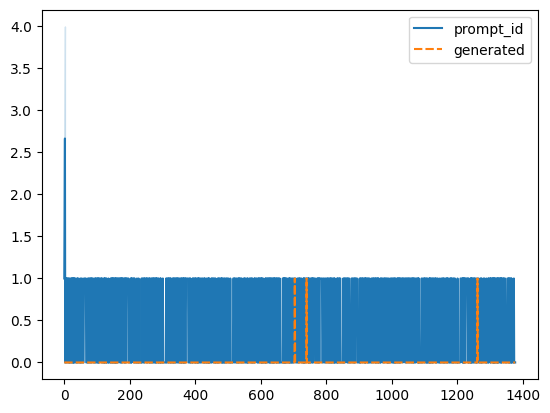

In [21]:
sns.lineplot(combined)

<Axes: >

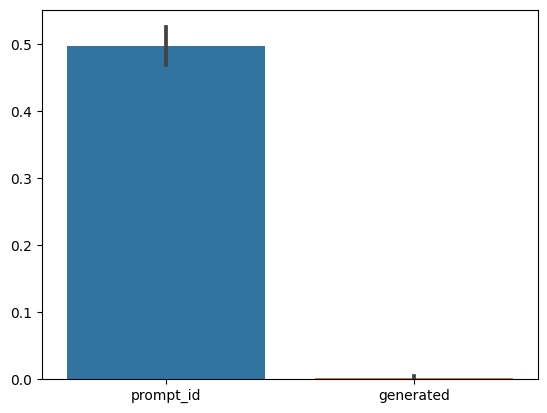

In [22]:
sns.barplot(combined)

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

<Axes: ylabel='Density'>

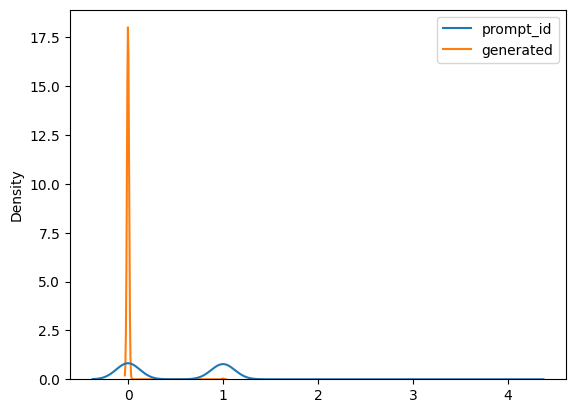

In [23]:
sns.kdeplot(combined)

In [24]:
combined.skew

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


<bound method DataFrame.skew of             id  prompt_id                                               text  \
0     0000aaaa          2                                       Aaa bbb ccc.   
1     1111bbbb          3                                       Bbb ccc ddd.   
2     2222cccc          4                                       CCC ddd eee.   
0     0000aaaa          2                                       Aaa bbb ccc.   
1     1111bbbb          3                                       Bbb ccc ddd.   
...        ...        ...                                                ...   
1375  ffa247e0          0  There's a new trend that has been developing f...   
1376  ffc237e9          0  As we all know cars are a big part of our soci...   
1377  ffe1ca0d          0  Cars have been around since the 1800's and hav...   
0          NaN          0                                                NaN   
1          NaN          1                                                NaN   

      g

In [25]:
combined.kurt

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


<bound method DataFrame.kurt of             id  prompt_id                                               text  \
0     0000aaaa          2                                       Aaa bbb ccc.   
1     1111bbbb          3                                       Bbb ccc ddd.   
2     2222cccc          4                                       CCC ddd eee.   
0     0000aaaa          2                                       Aaa bbb ccc.   
1     1111bbbb          3                                       Bbb ccc ddd.   
...        ...        ...                                                ...   
1375  ffa247e0          0  There's a new trend that has been developing f...   
1376  ffc237e9          0  As we all know cars are a big part of our soci...   
1377  ffe1ca0d          0  Cars have been around since the 1800's and hav...   
0          NaN          0                                                NaN   
1          NaN          1                                                NaN   

      g

In [26]:
cat_cols = combined.select_dtypes(include='object')

In [27]:
for i in cat_cols:
    combined[i].value_counts()
    print(i)
    print(''*50)

id

text

prompt_name

instructions

source_text



In [28]:
num_cols = combined.select_dtypes(include='number')

In [29]:
for i in num_cols:
    combined[i].value_counts()
    print(i)
    print(''*50)

prompt_id

generated



(array([0, 1]), [Text(0, 0, 'prompt_id'), Text(1, 0, 'generated')])

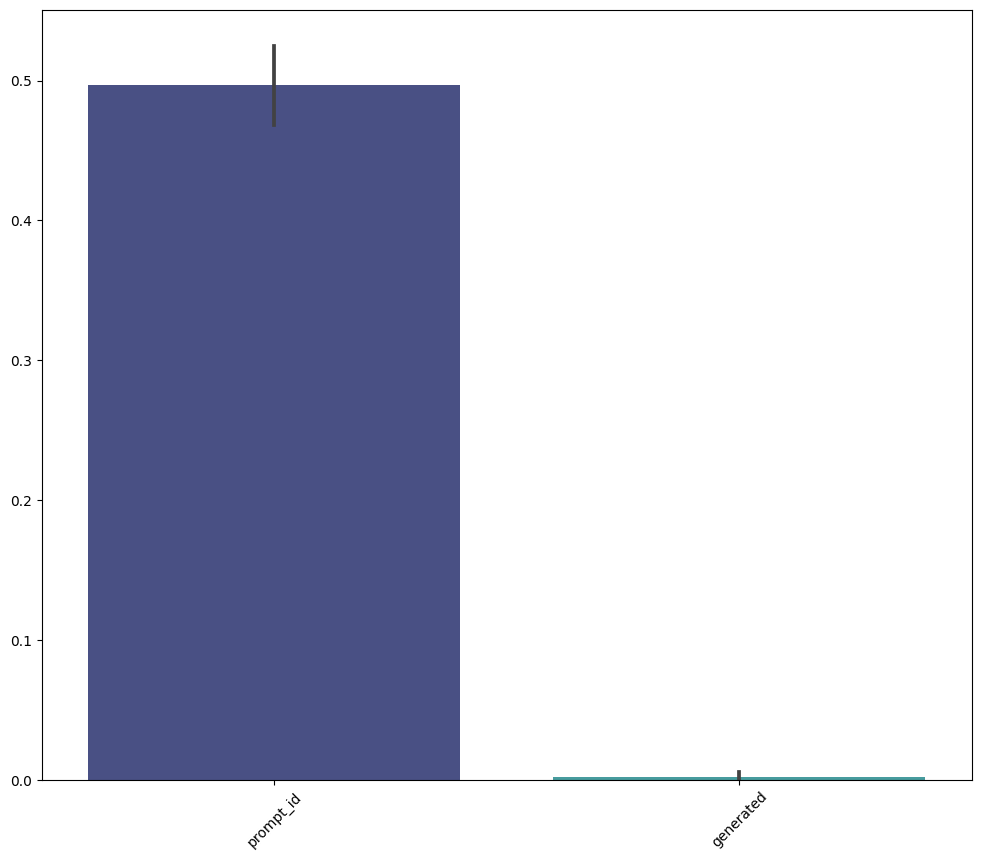

In [30]:
plt.figure(figsize=(12,10))
sns.barplot(data=combined,palette='mako')
plt.xticks(rotation=45)

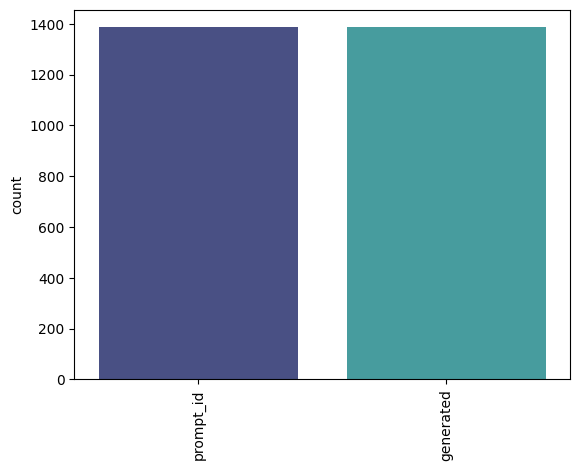

In [31]:
sns.countplot(data=combined,palette='mako');
plt.xticks(rotation=90);

(array([-200.,    0.,  200.,  400.,  600.,  800., 1000., 1200., 1400.,
        1600.]),
 [Text(-200.0, 0, '−200'),
  Text(0.0, 0, '0'),
  Text(200.0, 0, '200'),
  Text(400.0, 0, '400'),
  Text(600.0, 0, '600'),
  Text(800.0, 0, '800'),
  Text(1000.0, 0, '1000'),
  Text(1200.0, 0, '1200'),
  Text(1400.0, 0, '1400'),
  Text(1600.0, 0, '1600')])

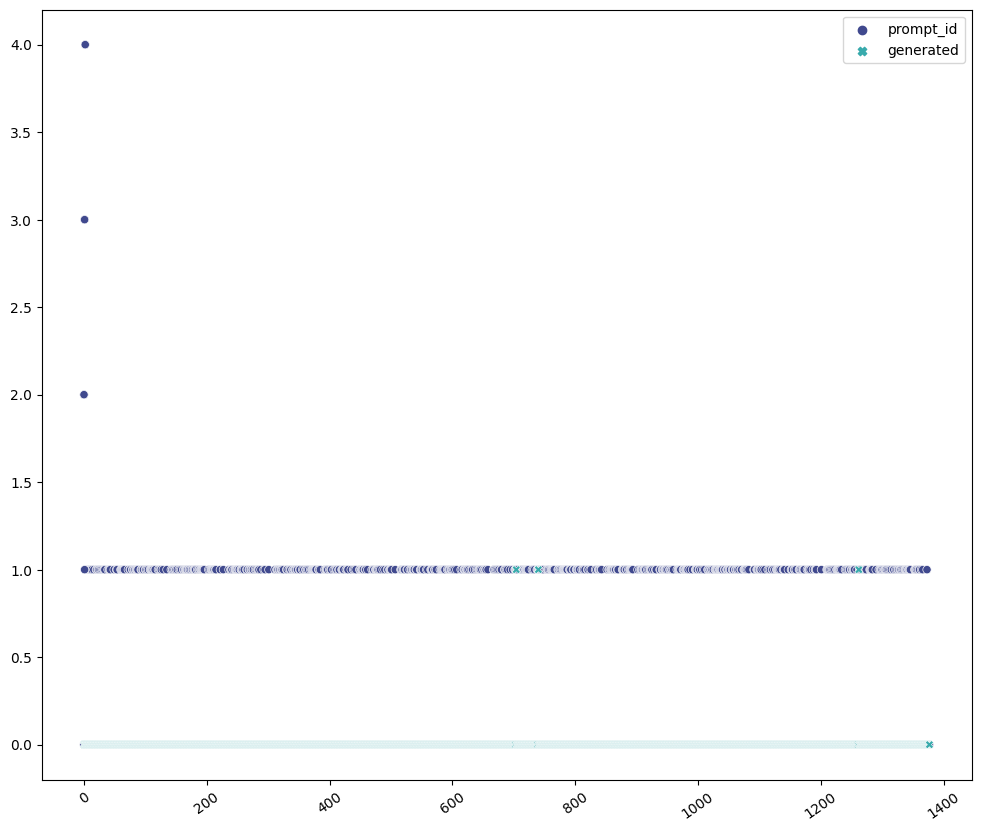

In [32]:
plt.figure(figsize=(12,10))
sns.scatterplot(data=combined,palette='mako');
plt.xticks(rotation=35)

In [33]:
combined.value_counts('id')

id
0000aaaa    2
1111bbbb    2
2222cccc    2
a6bb33d4    1
a648260a    1
           ..
5a810c9d    1
5a6c9d91    1
5a3184fb    1
5a2acdf7    1
ffe1ca0d    1
Name: count, Length: 1381, dtype: int64

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


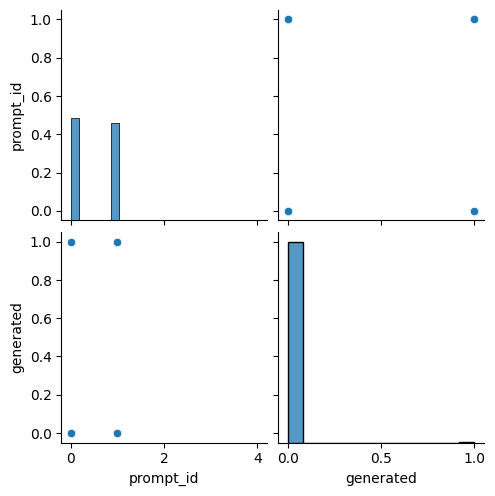

In [34]:
sns.pairplot(combined)

In [35]:
combined['id'].nunique()

1381

In [36]:
 # Replacing weird value
combined = combined.applymap(lambda x:x if x is np.NaN or not isinstance(x,str)else str(x).strip('_,"')
                            ).replace(['','nan','!@9#%8','#F%$D@*&8'],np.NaN)

<ipython-input-36-301a4e57379d>:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  combined = combined.applymap(lambda x:x if x is np.NaN or not isinstance(x,str)else str(x).strip('_,"')


In [37]:
combined.head()

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,prompt_id,text,generated,prompt_name,instructions,source_text
0,0000aaaa,2,Aaa bbb ccc.,NaN,NaN,NaN,NaN
1,1111bbbb,3,Bbb ccc ddd.,NaN,NaN,NaN,NaN
2,2222cccc,4,CCC ddd eee.,NaN,NaN,NaN,NaN
0,0000aaaa,2,Aaa bbb ccc.,NaN,NaN,NaN,NaN
1,1111bbbb,3,Bbb ccc ddd.,NaN,NaN,NaN,NaN


In [38]:
# Treating type of id
combined['id'].value_counts().head(9).index[1:]

Index(['2222cccc', '1111bbbb', 'ffc237e9', 'a47cee9d', 'a623a791', 'a5fd6487',
       'a5c3c7a1', 'a5a50bf5'],
      dtype='object', name='id')

In [39]:
# Rebuild type of id columns
for i in combined['id'].value_counts().head(9).index[1:]:
    combined[i]=combined['id'].str.contains(i)

In [40]:
combined.head()

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,prompt_id,text,generated,prompt_name,instructions,source_text,2222cccc,1111bbbb,ffc237e9,a47cee9d,a623a791,a5fd6487,a5c3c7a1,a5a50bf5
0,0000aaaa,2,Aaa bbb ccc.,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False
1,1111bbbb,3,Bbb ccc ddd.,NaN,NaN,NaN,NaN,False,True,False,False,False,False,False,False
2,2222cccc,4,CCC ddd eee.,NaN,NaN,NaN,NaN,True,False,False,False,False,False,False,False
0,0000aaaa,2,Aaa bbb ccc.,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False
1,1111bbbb,3,Bbb ccc ddd.,NaN,NaN,NaN,NaN,False,True,False,False,False,False,False,False


In [41]:
cat_cols.shape,num_cols.shape

((1386, 5), (1386, 2))

In [42]:
combined['id'].unique()

array(['0000aaaa', '1111bbbb', '2222cccc', ..., 'ffc237e9', 'ffe1ca0d',
       nan], dtype=object)

In [43]:
cat_cols

,id,text,prompt_name,instructions,source_text
0,0000aaaa,Aaa bbb ccc.,NaN,NaN,NaN
1,1111bbbb,Bbb ccc ddd.,NaN,NaN,NaN
2,2222cccc,CCC ddd eee.,NaN,NaN,NaN
0,0000aaaa,Aaa bbb ccc.,NaN,NaN,NaN
1,1111bbbb,Bbb ccc ddd.,NaN,NaN,NaN
...,...,...,...,...,...
1375,ffa247e0,There's a new trend that has been developing f...,NaN,NaN,NaN
1376,ffc237e9,As we all know cars are a big part of our soci...,NaN,NaN,NaN
1377,ffe1ca0d,Cars have been around since the 1800's and hav...,NaN,NaN,NaN
0,NaN,NaN,Car-free cities,Write an explanatory essay to inform fellow ci...,"# In German Suburb, Life Goes On Without Cars ..."


In [44]:
num_cols

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,prompt_id,generated
0,2,NaN
1,3,NaN
2,4,NaN
0,2,NaN
1,3,NaN
...,...,...
1375,0,0.0
1376,0,0.0
1377,0,0.0
0,0,NaN


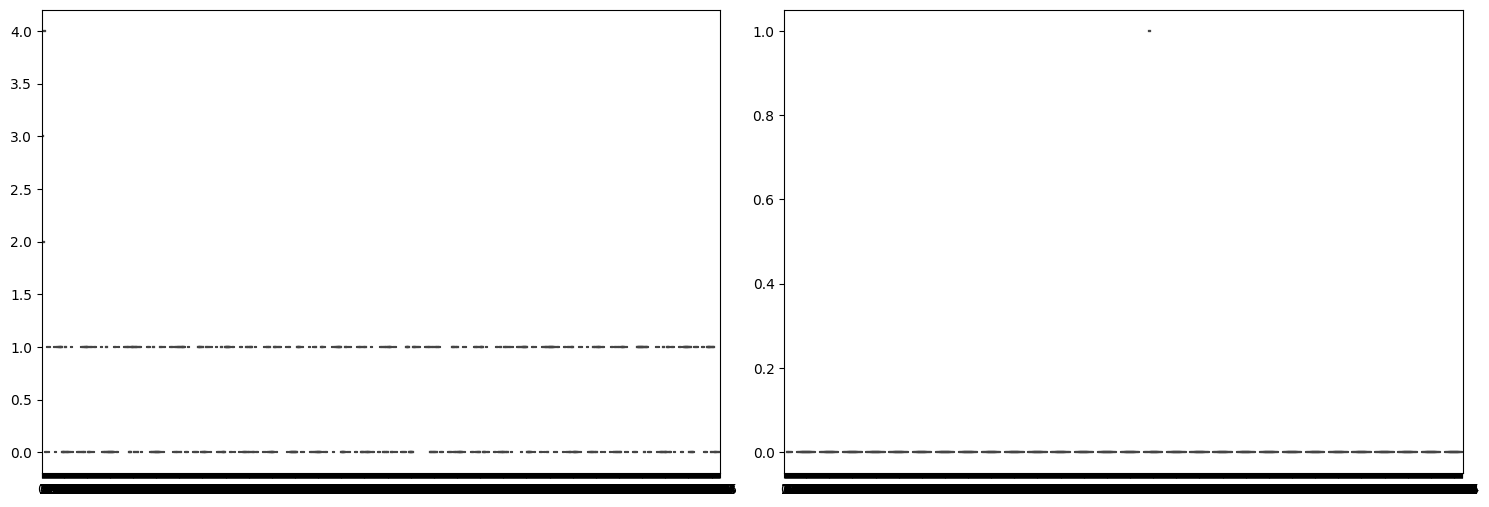

In [59]:
plt.figure(figsize=(15,20))
iterator=1
for i in num_cols:
    plt.subplot(4,2,iterator)
    sns.boxplot(combined[i])
    iterator+=1
plt.tight_layout()

In [ ]:
# multivariate analysis for cat cols

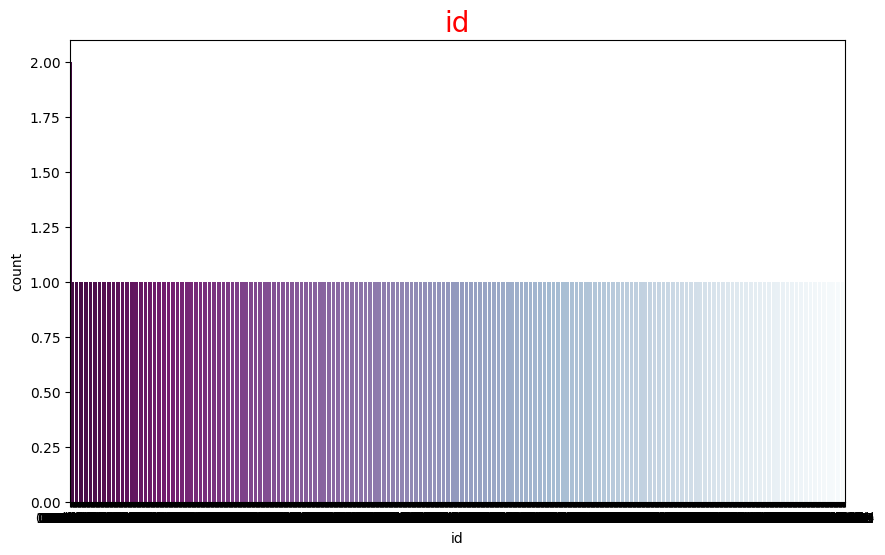

In [46]:
plt.figure(figsize=(10,6))
sns.countplot(data=combined,x ='id',palette='BuPu_r')
plt.title('id',size=20,color='red')
plt.show() 

In [47]:
combined['prompt_id'].value_counts(normalize=True)*100

prompt_id
0    51.154401
1    48.412698
2     0.144300
3     0.144300
4     0.144300
Name: proportion, dtype: float64

In [48]:
train.shape[0]

1378

In [49]:
new_train=combined.iloc[0:train.shape[0],:]

In [50]:
new_test=combined.iloc[train.shape[0]:,:]

In [51]:
train.shape,new_train.shape,test.shape,new_test.shape

((1378, 4), (1378, 15), (3, 3), (8, 15))

In [52]:
combined.head()

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,prompt_id,text,generated,prompt_name,instructions,source_text,2222cccc,1111bbbb,ffc237e9,a47cee9d,a623a791,a5fd6487,a5c3c7a1,a5a50bf5
0,0000aaaa,2,Aaa bbb ccc.,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False
1,1111bbbb,3,Bbb ccc ddd.,NaN,NaN,NaN,NaN,False,True,False,False,False,False,False,False
2,2222cccc,4,CCC ddd eee.,NaN,NaN,NaN,NaN,True,False,False,False,False,False,False,False
0,0000aaaa,2,Aaa bbb ccc.,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False
1,1111bbbb,3,Bbb ccc ddd.,NaN,NaN,NaN,NaN,False,True,False,False,False,False,False,False


In [53]:
# scaling the col
scaling =['prompt_id','id','generated']

In [54]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [55]:
train

,id,prompt_id,text,generated
0,0059830c,0,Cars. Cars have been around since they became ...,0
1,005db917,0,Transportation is a large necessity in most co...,0
2,008f63e3,0,"""America's love affair with it's vehicles seem...",0
3,00940276,0,How often do you ride in a car? Do you drive a...,0
4,00c39458,0,Cars are a wonderful thing. They are perhaps o...,0
...,...,...,...,...
1373,fe6ff9a5,1,There has been a fuss about the Elector Colleg...,0
1374,ff669174,0,Limiting car usage has many advantages. Such a...,0
1375,ffa247e0,0,There's a new trend that has been developing f...,0
1376,ffc237e9,0,As we all know cars are a big part of our soci...,0


In [56]:
# encoding
train_encoded=pd.get_dummies(train,drop_first=True)

In [57]:
test_encoded=pd.get_dummies(test,drop_first=True)

In [61]:
combined.head()

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,prompt_id,text,generated,prompt_name,instructions,source_text,2222cccc,1111bbbb,ffc237e9,a47cee9d,a623a791,a5fd6487,a5c3c7a1,a5a50bf5
0,0000aaaa,2,Aaa bbb ccc.,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False
1,1111bbbb,3,Bbb ccc ddd.,NaN,NaN,NaN,NaN,False,True,False,False,False,False,False,False
2,2222cccc,4,CCC ddd eee.,NaN,NaN,NaN,NaN,True,False,False,False,False,False,False,False
0,0000aaaa,2,Aaa bbb ccc.,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False
1,1111bbbb,3,Bbb ccc ddd.,NaN,NaN,NaN,NaN,False,True,False,False,False,False,False,False
